# 0. Set up

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap # Dùng để giải thích mô hình
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import xgboost as xgb
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import HuberRegressor
from prophet import Prophet
import time
import math
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from lunardate import LunarDate

In [114]:
df_train = pd.read_csv(filepath_or_buffer='datathon-2026-round-1\sales.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
df_test = pd.read_csv(filepath_or_buffer='datathon-2026-round-1\sample_submission.csv', parse_dates=['Date'])

print(f'Train: {df_train.Date.min().date()} -> {df_train.Date.max().date()} ({len(df_train)} ngay)')
print(f'Test:  {df_test.Date.min().date()} -> {df_test.Date.max().date()} ({len(df_test)} ngay)')

Train: 2012-07-04 -> 2022-12-31 (3833 ngay)
Test:  2023-01-01 -> 2024-07-01 (548 ngay)


# 1. Check other tables' patterns for feature engineering

## 1.1. Promotions

In [115]:
df_promotions = pd.read_csv(filepath_or_buffer='datathon-2026-round-1\promotions.csv')
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

In [116]:
df_promotions['promo_name2'] = df_promotions['promo_name'].str.replace(r' \d{4}$', '', regex=True)
# Tạo cột year từ start_date
df_promotions['year'] = df_promotions['start_date'].dt.year

# Tạo cột date_range để lưu khoảng ngày (chỉ tháng-ngày)
df_promotions['date_range'] = df_promotions['start_date'].dt.strftime('%m-%d') + ' to ' + df_promotions['end_date'].dt.strftime('%m-%d')

# Tạo pivot table: promo_name2 là hàng, year là cột, date_range là giá trị
pivot_promo = df_promotions.pivot_table(
    index='promo_name2',
    columns='year',
    values='date_range',
    aggfunc='first'  # Nếu có nhiều row thì lấy giá trị đầu tiên
)

pivot_promo

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
promo_name2,,,,,,,,,,
Fall Launch,08-30 to 10-02,08-30 to 10-01,08-30 to 10-01,08-30 to 10-01,08-30 to 10-02,08-30 to 10-01,08-30 to 10-01,08-30 to 10-01,08-30 to 10-02,08-31 to 10-01
Mid-Year Sale,06-23 to 07-22,06-23 to 07-22,06-23 to 07-22,06-23 to 07-22,06-23 to 07-22,06-23 to 07-22,06-23 to 07-22,06-23 to 07-22,06-23 to 07-22,06-23 to 07-22
Rural Special,01-31 to 03-01,NaN,01-30 to 03-01,NaN,01-30 to 03-01,NaN,01-30 to 03-01,NaN,01-30 to 03-01,NaN
Spring Sale,03-18 to 04-17,03-18 to 04-17,03-18 to 04-17,03-18 to 04-17,03-18 to 04-17,03-18 to 04-17,03-18 to 04-17,03-18 to 04-17,03-18 to 04-17,03-18 to 04-17
Urban Blowout,07-30 to 09-02,NaN,07-30 to 09-02,NaN,07-30 to 09-02,NaN,07-30 to 09-02,NaN,07-30 to 09-02,NaN
Year-End Sale,11-18 to 01-02,11-19 to 01-02,11-18 to 01-02,11-18 to 01-02,11-18 to 01-02,11-18 to 01-02,11-18 to 01-02,11-18 to 01-01,11-18 to 01-02,11-18 to 12-31


Nhóm thấy doanh nghiệp tổ chức các chương trình khuyến mãi diễn ra cố định tại 1 khung thời gian quanh năm, ngoại trừ rural special và urban blowout chỉ diễn ra ở các năm lẻ. Vì vậy nhóm sẽ xây dựng các features khuyến mãi dựa trên pattern này.

# 2. EDA sales.csv

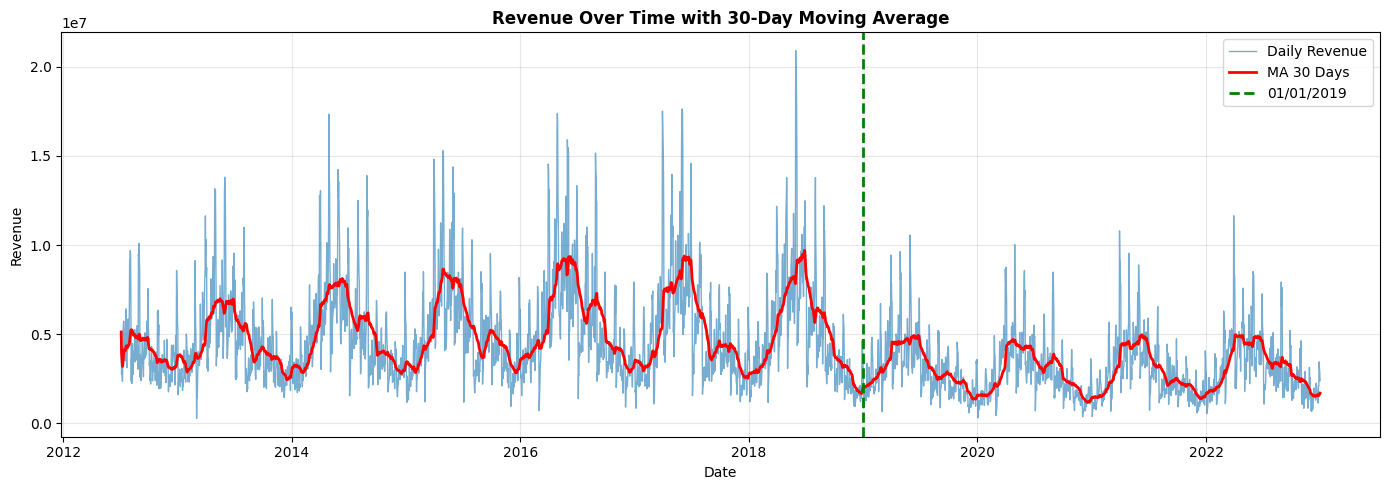

In [117]:
# Tính Moving Average 30 ngày
df_eda = df_train.copy()
df_eda['Revenue_MA30'] = df_eda['Revenue'].rolling(window=30, min_periods=1).mean()

# Vẽ biểu đồ Revenue
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Định nghĩa mốc ngày 01/01/2019
reference_date = pd.to_datetime('2019-01-01')

# Chart 1: Revenue
axes.plot(df_eda['Date'], df_eda['Revenue'], label='Daily Revenue', alpha=0.6, linewidth=1)
axes.plot(df_eda['Date'], df_eda['Revenue_MA30'], label='MA 30 Days', color='red', linewidth=2)
axes.axvline(reference_date, color='green', linestyle='--', linewidth=2, label='01/01/2019')
axes.set_title('Revenue Over Time with 30-Day Moving Average', fontsize=12, fontweight='bold')
axes.set_xlabel('Date')
axes.set_ylabel('Revenue')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



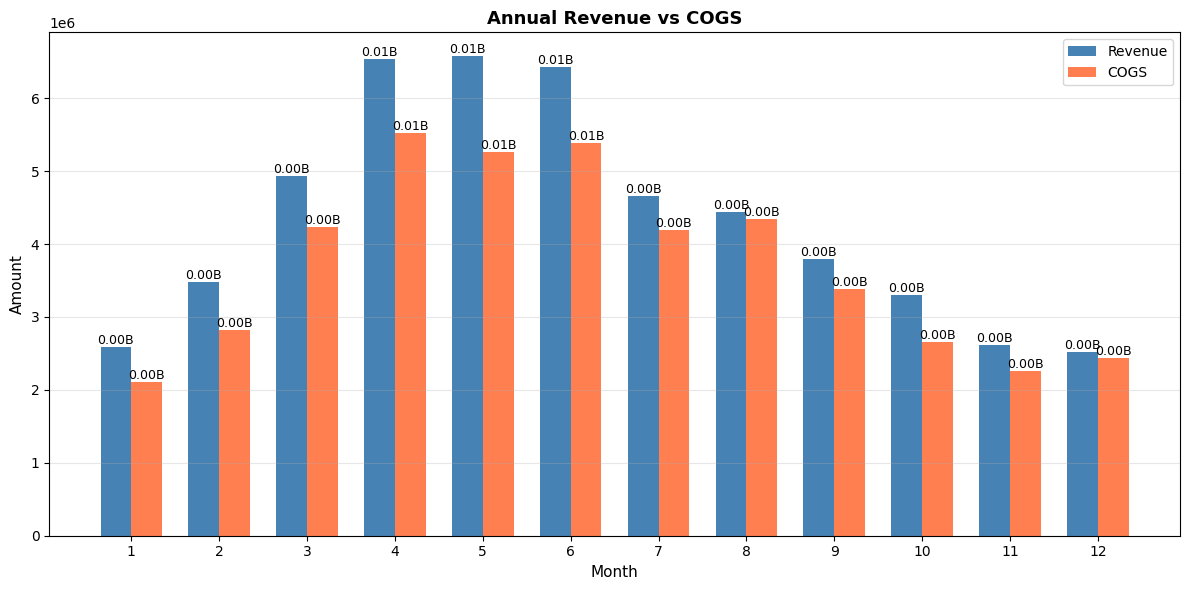

In [118]:
# Tạo cột year từ Date
df_eda['Month'] = df_eda['Date'].dt.month

# Group by year và tính tổng Revenue và COGS
yearly_data = df_eda.groupby('Month')[['Revenue', 'COGS']].mean().reset_index()

# Vẽ grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(yearly_data))
width = 0.35

bars1 = ax.bar(x - width/2, yearly_data['Revenue'], width, label='Revenue', color='steelblue')
bars2 = ax.bar(x + width/2, yearly_data['COGS'], width, label='COGS', color='coral')

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Amount', fontsize=11)
ax.set_title('Annual Revenue vs COGS', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(yearly_data['Month'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Thêm giá trị trên mỗi bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height/1e9:.2f}B',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 3. Feature engineer

In [119]:
def calendar(df):
    """
    Tạo các feature về calendar và cycle từ cột Date
    Features được tạo:
    - Year, Month, Day, Quarter, DayOfWeek, DayOfYear, WeekOfYear
    - IsWeekend, IsMonday, IsFriday
    - Month_sin, Month_cos (chu kỳ hàng tháng)
    - DayOfWeek_sin, DayOfWeek_cos (chu kỳ hàng tuần)
    - DayOfYear_sin, DayOfYear_cos (chu kỳ hàng năm)
    
    Args:
        df: DataFrame với cột 'Date' (datetime)
    
    Returns:
        DataFrame với các feature mới thêm vào
    """
    df = df.copy()
    
    # Đảm bảo Date là datetime
    if df['Date'].dtype != 'datetime64[ns]':
        df['Date'] = pd.to_datetime(df['Date'])
    
    # Basic calendar features
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['Quarter'] = df['Date'].dt.quarter
    df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['DayOfYear'] = df['Date'].dt.dayofyear
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week
    
    # Weekend/Weekday indicators
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)  # Saturday=5, Sunday=6
    df['IsMonday'] = (df['DayOfWeek'] == 0).astype(int)
    df['IsFriday'] = (df['DayOfWeek'] == 4).astype(int)
    
    # Cyclical encoding using sin/cos transformations
    # Giúp model hiểu rằng tháng 12 và tháng 1 gần nhau
    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    
    # Chu kỳ hàng tuần
    df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
    df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
    
    # Chu kỳ hàng năm
    df['DayOfYear_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
    df['DayOfYear_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)
    
    #df['Trend'] = (df['Date'] - pd.Timestamp('2012-01-01')).dt.days
    #is_post_2019 and is_prev_year_post_2019
    df['is_post_2019'] = (df['Date'] >= '2019-01-01').astype(int)
    df['is_prev_year_post_2019'] = (df['Date'] >= '2020-01-01').astype(int)
    return df


In [120]:
# Tạo tet_dates từ LunarDate(year, 1, 1).toSolarDate()
tet_dates = {year: pd.Timestamp(LunarDate(year, 1, 1).toSolarDate()) 
                 for year in range(2024, 2031)}
def get_tet_feature(date):
    year = date.year
        
        # Lấy Tết năm hiện tại và năm sau
    tet_current = tet_dates.get(year, pd.Timestamp(LunarDate(year, 1, 1).toSolarDate()))
    tet_next = tet_dates.get(year + 1, pd.Timestamp(LunarDate(year + 1, 1, 1).toSolarDate()))

        # Xác định Tết gần nhất
    if date < tet_current:
        nearest_tet = tet_current
        days_to_tet = -(tet_current - date).days
    else:
        nearest_tet = tet_next
        days_to_tet = (date - tet_current).days
        
    return days_to_tet, nearest_tet
def tet_holiday(df):
    """
    Tạo các feature liên quan đến Tết (Tết Nguyên Đán) từ cột Date
    Features được tạo:
    - day_to_tet: Số ngày từ date hiện tại đến Tết gần nhất
    - is_pre_tet_1_week: 1 tuần trước Tết
    - is_pre_tet_2_week: 2 tuần trước Tết
    - is_post_tet_1_week: 1 tuần sau Tết
    - is_post_tet_2_week: 2 tuần sau Tết
    """  
    
    df = df.copy()
    if df['Date'].dtype != 'datetime64[ns]':
        df['Date'] = pd.to_datetime(df['Date'])

    # Tính day_to_tet và nearest_tet
    tet_features = df['Date'].apply(get_tet_feature)
    df['day_to_tet'] = tet_features.apply(lambda x: x[0])
    
    # Tạo boolean features
    df['is_pre_tet_1_week'] = ((df['day_to_tet'] >= -7) & (df['day_to_tet'] < 0)).astype(int)
    df['is_pre_tet_2_week'] = ((df['day_to_tet'] >= -14) & (df['day_to_tet'] < -7)).astype(int)
    df['is_post_tet_1_week'] = ((df['day_to_tet'] >= 0) & (df['day_to_tet'] < 7)).astype(int)
    df['is_post_tet_2_week'] = ((df['day_to_tet'] >= 7) & (df['day_to_tet'] < 14)).astype(int)
    
    return df

In [121]:
def national_holiday(df):
    """
    Tạo các feature binary cho các ngày lễ Việt Nam
    Kiểm tra xem row có nằm trong 2 tuần (14 ngày) trước các ngày lễ không
    
    Các ngày lễ bao gồm:
    - 8/3: Ngày Quốc tế Phụ nữ
    - 20/10: Ngày Phụ nữ Việt Nam
    - 20/11: Ngày Nhà giáo Việt Nam
    - 25/12: Giáng sinh
    - 9/2: Quốc khánh
    - 30/4: Ngày Giải phóng/Thống nhất
    
    Features được tạo:
    - is_before_8_3, is_before_20_10, is_before_20_11, is_before_xmas,
      is_before_national_day, is_before_liberation_day
    """
    df = df.copy()
    
    if df['Date'].dtype != 'datetime64[ns]':
        df['Date'] = pd.to_datetime(df['Date'])
    
    # Định nghĩa các ngày lễ (tháng-ngày)
    holidays = {
        'women_day': (3, 8),          # 8/3
        'vietnam_women_day': (10, 20),# 20/10
        'teacher_day': (11, 20),      # 20/11
        'xmas': (12, 25),             # Giáng sinh
        'national_day': (9, 2),       # Quốc khánh
        'liberation_day': (4, 30),    # Ngày Giải phóng
    }
    
    def is_before_holiday(date, holiday_month, holiday_day, days_before=14):
        """
        Kiểm tra xem date có nằm trong khoảng [holiday - days_before, holiday) không
        """
        year = date.year
        holiday_date = pd.Timestamp(year=year, month=holiday_month, day=holiday_day)
        
        # Nếu date đã qua ngày lễ năm nay, so sánh với ngày lễ năm sau
        if date >= holiday_date:
            holiday_date = pd.Timestamp(year=year + 1, month=holiday_month, day=holiday_day)
        
        # Kiểm tra xem date có nằm trong 14 ngày trước ngày lễ không
        start_date = holiday_date - pd.Timedelta(days=days_before)
        return (date >= start_date) & (date < holiday_date)
    
    # Tạo các cột binary cho từng ngày lễ
    for holiday_name, (month, day) in holidays.items():
        col_name = f'is_before_{holiday_name}'
        df[col_name] = df['Date'].apply(
            lambda x: is_before_holiday(x, month, day)
        ).astype(int)
    
    return df



In [122]:

# Định nghĩa các khuyến mãi
promotions = [
    {'name': 'Fall Launch', 'start': (8, 30), 'end': (10, 1), 'odd_years_only': False},
    {'name': 'Mid-Year Sale', 'start': (6, 23), 'end': (7, 22), 'odd_years_only': False},
    {'name': 'Rural Special', 'start': (1, 31), 'end': (3, 1), 'odd_years_only': True},
    {'name': 'Spring Sale', 'start': (3, 18), 'end': (4, 17), 'odd_years_only': False},
    {'name': 'Urban Blowout', 'start': (7, 30), 'end': (9, 2), 'odd_years_only': True},
    {'name': 'Year-End Sale', 'start': (11, 18), 'end': (1, 2), 'span_year': True, 'odd_years_only': False},
]

def promotion(df):
    """
    Tạo các feature liên quan đến khuyến mãi cố định
    
    Các khuyến mãi được set up sẵn:
    - Fall Launch: 30/08 -> 01/10
    - Mid-Year Sale: 23/06 -> 22/07
    - Rural Special: 31/01 -> 01/03 (năm lẻ)
    - Spring Sale: 18/03 -> 17/04
    - Urban Blowout: 30/07 -> 02/09 (năm lẻ)
    - Year-End Sale: 18/11 -> 02/01 (năm sau)
    
    Features được tạo:
    - is_fall_launch, is_mid_year_sale, is_rural_special, is_spring_sale, is_urban_blowout, is_year_end_sale
    
    Args:
        df: DataFrame với cột 'Date' (datetime)
        
    Returns:
        DataFrame với các cột is_promo_day và promo_name thêm vào
    """
    df = df.copy()
    
    # Đảm bảo cột Date đúng định dạng
    if not pd.api.types.is_datetime64_any_dtype(df['Date']):
        df['Date'] = pd.to_datetime(df['Date'])
    
    # Tạo các cột phụ để tính toán nhanh (vectorized)
    month = df['Date'].dt.month
    day = df['Date'].dt.day
    year = df['Date'].dt.year
    # Chuyển đổi tháng/ngày thành một số nguyên (ví dụ 12 tháng 31 -> 1231) để so sánh nhanh
    md = month * 100 + day 

    promo_cols = []

    for promo in promotions:
        # Chuẩn hóa tên cột: is_fall_launch, is_rural_special,...
        col_name = 'is_' + promo['name'].lower().replace(' ', '_').replace('-', '_')
        promo_cols.append(col_name)
        
        start_md = promo['start'][0] * 100 + promo['start'][1]
        end_md = promo['end'][0] * 100 + promo['end'][1]
        
        # 1. Kiểm tra điều kiện ngày tháng
        if promo.get('span_year', False):
            # Nếu xuyên năm (ví dụ 1118 đến 0102): Ngày >= 1118 HOẶC Ngày <= 0102
            mask = (md >= start_md) | (md <= end_md)
        else:
            # Nếu trong cùng năm: Ngày >= Start AND Ngày <= End
            mask = (md >= start_md) & (md <= end_md)
        
        # 2. Kiểm tra điều kiện năm lẻ (Rural Special & Urban Blowout)
        if promo.get('odd_years_only', False):
            mask &= (year % 2 != 0)
            
        # Gán giá trị 1/0
        df[col_name] = mask.astype(int)
    
  
    return df


In [123]:
def peak_proximity(df):
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df['Date']):
        df['Date'] = pd.to_datetime(df['Date'])
        
    def get_days_to_peak(date):
        year = date.year
        peaks = [
            pd.Timestamp(year, 4, 1),
            pd.Timestamp(year, 5, 1),
            pd.Timestamp(year, 6, 1),
            pd.Timestamp(year-1, 6, 1),
            pd.Timestamp(year+1, 4, 1)
        ]
        return min(abs((date - p).days) for p in peaks)
        
    df['days_to_peak'] = df['Date'].apply(get_days_to_peak)
    df['peak_proximity'] = 1 / (1 + df['days_to_peak'])
    df = df.drop(columns=['days_to_peak'])
    return df

In [124]:


def feature_engineer(df):
    """
    Xây dựng toàn bộ các feature cho dataframe
   
    """
    df = df.copy()
    df = df.sort_values('Date')

    df = calendar(df)
    # Không dùng các biến bên ngoài 
    # df = tet_holiday(df)
    # df = national_holiday(df)
    # df = promotion(df)
    df = peak_proximity(df)

    return df


# 3. Forecasting

## 3.1. Khởi tạo hàm đánh giá Metrics

In [126]:

def evaluate_metrics(y_true, y_pred, model_name="Model", target_name="Target"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{model_name} - {target_name}] MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

## 3.2. Split Data

In [127]:
print("--- RESIDUAL LEARNING WITH PROPHET & ML (WALK-FORWARD + HUBER) ---")
df_train_raw = df_train.copy()
df_train_raw['Revenue_log'] = np.log1p(df_train_raw['Revenue'])

# Áp dụng feature engineer hiện tại 
df_train_full_fe = feature_engineer(df_train_raw)

features = [c for c in df_train_full_fe.columns if c not in ['Date', 'Revenue', 'COGS', 'Revenue_log', 'residual']]

folds = [
    ('2012-07-04', '2018-12-31', '2019-01-01', '2019-12-31'),
    ('2012-07-04', '2019-12-31', '2020-01-01', '2020-12-31'),
    ('2012-07-04', '2020-12-31', '2021-01-01', '2021-12-31'),
    ('2012-07-04', '2021-12-31', '2022-01-01', '2022-12-31')
]

cached_folds = []
for train_start, train_end, val_start, val_end in folds:
    train_fold = df_train_full_fe[(df_train_full_fe['Date'] >= train_start) & (df_train_full_fe['Date'] <= train_end)].copy()
    val_fold = df_train_full_fe[(df_train_full_fe['Date'] >= val_start) & (df_train_full_fe['Date'] <= val_end)].copy()
    
    prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    prophet_df = train_fold[['Date', 'Revenue_log']].rename(columns={'Date': 'ds', 'Revenue_log': 'y'})
    prophet.fit(prophet_df)
    
    train_fold['residual'] = train_fold['Revenue_log'] - prophet.predict(prophet_df)['yhat'].values
    val_trend = prophet.predict(val_fold[['Date']].rename(columns={'Date': 'ds'}))['yhat'].values
    val_fold['residual'] = val_fold['Revenue_log'] - val_trend
    
    cached_folds.append({
        'X_train': train_fold[features], 'y_train_res': train_fold['residual'],
        'X_val': val_fold[features], 'y_val_res': val_fold['residual'],
        'val_trend': val_trend, 'y_val_true_rev': val_fold['Revenue']
    })





--- RESIDUAL LEARNING WITH PROPHET & ML (WALK-FORWARD + HUBER) ---


22:16:18 - cmdstanpy - INFO - Chain [1] start processing
22:16:18 - cmdstanpy - INFO - Chain [1] done processing
22:16:19 - cmdstanpy - INFO - Chain [1] start processing
22:16:19 - cmdstanpy - INFO - Chain [1] done processing
22:16:20 - cmdstanpy - INFO - Chain [1] start processing
22:16:20 - cmdstanpy - INFO - Chain [1] done processing
22:16:21 - cmdstanpy - INFO - Chain [1] start processing
22:16:22 - cmdstanpy - INFO - Chain [1] done processing


## 3.3. Fine-tune base models

In [128]:

def objective_xgb(trial):
    params = {
        'n_estimators': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'objective': 'reg:pseudohubererror', 'device': 'cuda', 'tree_method': 'hist', 'random_state': 42
    }
    cv_maes = []
    for fold in cached_folds:
        model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
        model.fit(fold['X_train'], fold['y_train_res'], eval_set=[(fold['X_val'], fold['y_val_res'])], verbose=False)
        val_pred_rev = np.expm1(fold['val_trend'] + model.predict(fold['X_val'])) 
        cv_maes.append(mean_absolute_error(fold['y_val_true_rev'], val_pred_rev))
    return np.mean(cv_maes)

def objective_lgb(trial):
    params = {
        'n_estimators': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'huber', 'device': 'gpu', 'random_state': 42, 'verbose': -1
    }
    cv_maes = []
    for fold in cached_folds:
        model = lgb.LGBMRegressor(**params)
        model.fit(fold['X_train'], fold['y_train_res'], eval_set=[(fold['X_val'], fold['y_val_res'])], callbacks=[lgb.early_stopping(50, verbose=False)])
        val_pred_rev = np.expm1(fold['val_trend'] + model.predict(fold['X_val']))
        cv_maes.append(mean_absolute_error(fold['y_val_true_rev'], val_pred_rev))
    return np.mean(cv_maes)

def objective_cat(trial):
    params = {
        'iterations': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'loss_function': 'Huber:delta=1.5', 'task_type': 'CPU', 'random_state': 42, 'verbose': False
    }
    cv_maes = []
    for fold in cached_folds:
        model = CatBoostRegressor(**params, early_stopping_rounds=50)
        model.fit(fold['X_train'], fold['y_train_res'], eval_set=[(fold['X_val'], fold['y_val_res'])], verbose=False)
        val_pred_rev = np.expm1(fold['val_trend'] + model.predict(fold['X_val']))
        cv_maes.append(mean_absolute_error(fold['y_val_true_rev'], val_pred_rev))
    return np.mean(cv_maes)

print("Đang Tune XGBoost...")
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=30)

print("\nĐang Tune LightGBM...")
study_lgb = optuna.create_study(direction="minimize")
study_lgb.optimize(objective_lgb, n_trials=30)

print("\nĐang Tune CatBoost...")
study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(objective_cat, n_trials=30)

print("\nXong. Lưu best params để Stacking.")
best_xgb_params = study_xgb.best_trial.params
best_lgb_params = study_lgb.best_trial.params
best_cat_params = study_cat.best_trial.params

Đang Tune XGBoost...

Đang Tune LightGBM...

Đang Tune CatBoost...

Xong. Lưu best params để Stacking.


## 3.4. Stacking ensemble

In [129]:
print("--- WALK-FORWARD CV & OOF PREDICTIONS CHO META-MODEL ---")
xgb_params = {'n_estimators': 2000, 'objective': 'reg:pseudohubererror', 'device': 'cuda', 'tree_method': 'hist', 'random_state': 42}
lgb_params = {'n_estimators': 2000, 'objective': 'huber', 'device': 'gpu', 'random_state': 42, 'verbose': -1}
cat_params = {'iterations': 2000, 'loss_function': 'Huber:delta=1.5', 'task_type': 'CPU', 'random_state': 42, 'verbose': False}

xgb_params.update(best_xgb_params)
lgb_params.update(best_lgb_params)
cat_params.update(best_cat_params)

oof_rev_xgb, oof_rev_lgb, oof_rev_cat = [], [], []
oof_y_rev = []

for train_start, train_end, val_start, val_end in folds:
    train_fold = df_train_full_fe[(df_train_full_fe['Date'] >= train_start) & (df_train_full_fe['Date'] <= train_end)].copy()
    val_fold = df_train_full_fe[(df_train_full_fe['Date'] >= val_start) & (df_train_full_fe['Date'] <= val_end)].copy()
    
    prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    prophet_df = train_fold[['Date', 'Revenue_log']].rename(columns={'Date': 'ds', 'Revenue_log': 'y'})
    prophet.fit(prophet_df)
    
    train_trend = prophet.predict(prophet_df)['yhat'].values
    val_trend = prophet.predict(val_fold[['Date']].rename(columns={'Date': 'ds'}))['yhat'].values
    train_fold['residual'] = train_fold['Revenue_log'] - train_trend
    val_fold['residual'] = val_fold['Revenue_log'] - val_trend
    
    X_tr, X_va = train_fold[features], val_fold[features]
    
    # --- TRAIN BASE MODELS (REVENUE) ---
    m_rev_xgb = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=50)
    m_rev_xgb.fit(X_tr, train_fold['residual'], eval_set=[(X_va, val_fold['residual'])], verbose=False)
    
    m_rev_lgb = lgb.LGBMRegressor(**lgb_params)
    m_rev_lgb.fit(X_tr, train_fold['residual'], eval_set=[(X_va, val_fold['residual'])], callbacks=[lgb.early_stopping(50, verbose=False)])
    
    m_rev_cat = CatBoostRegressor(**cat_params, early_stopping_rounds=50)
    m_rev_cat.fit(X_tr, train_fold['residual'], eval_set=[(X_va, val_fold['residual'])], verbose=False)
    
    log_p_xgb_rev = val_trend + m_rev_xgb.predict(X_va)
    log_p_lgb_rev = val_trend + m_rev_lgb.predict(X_va)
    log_p_cat_rev = val_trend + m_rev_cat.predict(X_va)
    
    oof_rev_xgb.extend(log_p_xgb_rev)
    oof_rev_lgb.extend(log_p_lgb_rev)
    oof_rev_cat.extend(log_p_cat_rev)
    oof_y_rev.extend(val_fold['Revenue_log'])

oof_true_rev = np.expm1(oof_y_rev)
oof_pred_xgb = np.expm1(oof_rev_xgb)
oof_pred_lgb = np.expm1(oof_rev_lgb)
oof_pred_cat = np.expm1(oof_rev_cat)

print("\n--- ĐÁNH GIÁ PERFORMANCE BASE MODELS TRÊN TẬP VALIDATION (OOF) ---")
evaluate_metrics(oof_true_rev, oof_pred_xgb, model_name="XGBoost", target_name="Revenue")
evaluate_metrics(oof_true_rev, oof_pred_lgb, model_name="LightGBM", target_name="Revenue")
evaluate_metrics(oof_true_rev, oof_pred_cat, model_name="CatBoost", target_name="Revenue")

print("\n--- TRAINING META-MODELS (HUBER REGRESSOR) ---")
X_meta_rev = np.column_stack([oof_rev_xgb, oof_rev_lgb, oof_rev_cat])
huber_grid = {'epsilon': [1.2, 1.25, 1.35, 1.4, 1.45, 1.5], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
meta_rev_search = GridSearchCV(HuberRegressor(fit_intercept=False), huber_grid, cv=5, scoring='neg_mean_absolute_error')
meta_rev_search.fit(X_meta_rev, oof_y_rev)
meta_rev_model = meta_rev_search.best_estimator_

print(f" -> Trọng số Meta Model (Revenue): {meta_rev_model.coef_}")

oof_pred_meta_log = meta_rev_model.predict(X_meta_rev)
oof_pred_meta = np.expm1(oof_pred_meta_log)

print("\n--- ĐÁNH GIÁ PERFORMANCE META-MODEL TRÊN TẬP VALIDATION (OOF) ---")
evaluate_metrics(oof_true_rev, oof_pred_meta, model_name="Meta-Model (Huber)", target_name="Revenue")



--- WALK-FORWARD CV & OOF PREDICTIONS CHO META-MODEL ---


22:23:03 - cmdstanpy - INFO - Chain [1] start processing
22:23:03 - cmdstanpy - INFO - Chain [1] done processing
22:23:06 - cmdstanpy - INFO - Chain [1] start processing
22:23:06 - cmdstanpy - INFO - Chain [1] done processing
22:23:11 - cmdstanpy - INFO - Chain [1] start processing
22:23:11 - cmdstanpy - INFO - Chain [1] done processing
22:23:14 - cmdstanpy - INFO - Chain [1] start processing
22:23:14 - cmdstanpy - INFO - Chain [1] done processing



--- ĐÁNH GIÁ PERFORMANCE BASE MODELS TRÊN TẬP VALIDATION (OOF) ---
[XGBoost - Revenue] MAE: 835688.62 | RMSE: 1140514.21 | R2: 0.5248
[LightGBM - Revenue] MAE: 827725.68 | RMSE: 1119201.49 | R2: 0.5424
[CatBoost - Revenue] MAE: 844171.85 | RMSE: 1161965.72 | R2: 0.5068

--- TRAINING META-MODELS (HUBER REGRESSOR) ---
 -> Trọng số Meta Model (Revenue): [0.29474999 0.62843023 0.08210347]

--- ĐÁNH GIÁ PERFORMANCE META-MODEL TRÊN TẬP VALIDATION (OOF) ---
[Meta-Model (Huber) - Revenue] MAE: 845880.52 | RMSE: 1175439.56 | R2: 0.4953


{'mae': 845880.5170518771,
 'rmse': 1175439.5646423248,
 'r2': 0.4953023222473878}

## 3.5. Final forecasting

In [130]:
print("\n--- DIRECT FORECASTING 548 DAYS TƯƠNG LAI ---")
# Feature Engineering for Future
df_future = df_test.copy()
df_future_fe = feature_engineer(df_future)

# Bỏ early_stopping, đặt n_estimators = 600
xgb_params.pop('early_stopping_rounds', None)
cat_params.pop('early_stopping_rounds', None)
xgb_params['n_estimators'] = 600
lgb_params['n_estimators'] = 600
cat_params['iterations'] = 600

# Retrain Prophet on Full
final_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_df_full = df_train_full_fe[['Date', 'Revenue_log']].rename(columns={'Date': 'ds', 'Revenue_log': 'y'})
final_prophet.fit(prophet_df_full)
df_train_full_fe['residual'] = df_train_full_fe['Revenue_log'] - final_prophet.predict(prophet_df_full)['yhat'].values

# Retrain ML Models
print("Retraining Base Models on Full Data...")
f_rev_xgb, f_rev_lgb, f_rev_cat = xgb.XGBRegressor(**xgb_params), lgb.LGBMRegressor(**lgb_params), CatBoostRegressor(**cat_params)
f_rev_xgb.fit(df_train_full_fe[features], df_train_full_fe['residual'], verbose=False)
f_rev_lgb.fit(df_train_full_fe[features], df_train_full_fe['residual'])
f_rev_cat.fit(df_train_full_fe[features], df_train_full_fe['residual'], verbose=False)

# Generating Meta-Predictions
test_trend = final_prophet.predict(df_future_fe[['Date']].rename(columns={'Date': 'ds'}))['yhat'].values

# Base Predictions (Revenue)
test_log_p_rev_xgb = test_trend + f_rev_xgb.predict(df_future_fe[features])
test_log_p_rev_lgb = test_trend + f_rev_lgb.predict(df_future_fe[features])
test_log_p_rev_cat = test_trend + f_rev_cat.predict(df_future_fe[features])

# Meta Model Inference
X_test_meta_rev = np.column_stack([test_log_p_rev_xgb, test_log_p_rev_lgb, test_log_p_rev_cat])

final_log_rev = meta_rev_model.predict(X_test_meta_rev)
df_future['Revenue'] = np.expm1(final_log_rev)
df_future['Revenue'] = df_future['Revenue'].clip(lower=0)

# Cập nhật Revenue vào df_test
df_test['Revenue'] = df_future['Revenue']




--- DIRECT FORECASTING 548 DAYS TƯƠNG LAI ---


22:23:21 - cmdstanpy - INFO - Chain [1] start processing
22:23:22 - cmdstanpy - INFO - Chain [1] done processing


Retraining Base Models on Full Data...


In [131]:
# 7. Xuất file Submission
# Giữ nguyên cấu trúc của df_test, chỉ Revenue được forecast
submission = df_test[['Date', 'Revenue', 'COGS']].copy()
submission.to_csv('submission.csv', index=False)
print("Đã lưu file submission.csv thành công!")
submission.head()



Đã lưu file submission.csv thành công!


,Date,Revenue,COGS
0,2023-01-01,3.313158e+06,2518885.15
1,2023-01-02,1.328030e+06,1136463.00
2,2023-01-03,1.043957e+06,822721.12
3,2023-01-04,1.042727e+06,914554.18
4,2023-01-05,1.008736e+06,984390.24


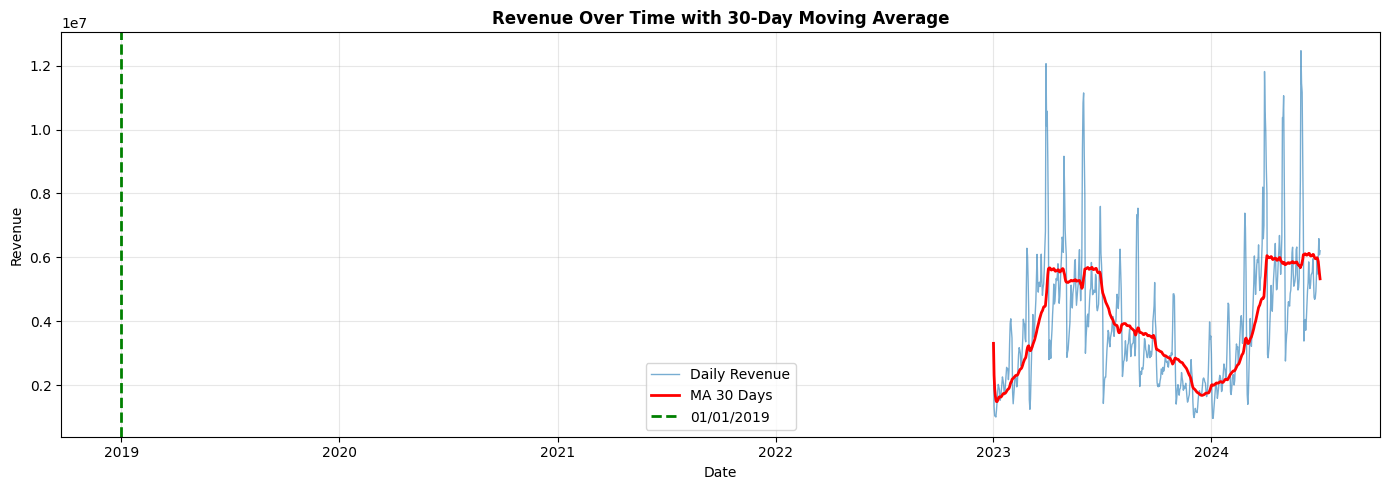

In [132]:
# Tính Moving Average 30 ngày
df_eda = submission.copy()
df_eda['Revenue_MA30'] = df_eda['Revenue'].rolling(window=30, min_periods=1).mean()

# Vẽ biểu đồ Revenue
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Định nghĩa mốc ngày 01/01/2019
reference_date = pd.to_datetime('2019-01-01')

# Chart 1: Revenue
axes.plot(df_eda['Date'], df_eda['Revenue'], label='Daily Revenue', alpha=0.6, linewidth=1)
axes.plot(df_eda['Date'], df_eda['Revenue_MA30'], label='MA 30 Days', color='red', linewidth=2)
axes.axvline(reference_date, color='green', linestyle='--', linewidth=2, label='01/01/2019')
axes.set_title('Revenue Over Time with 30-Day Moving Average', fontsize=12, fontweight='bold')
axes.set_xlabel('Date')
axes.set_ylabel('Revenue')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# 4. Shap values

Tính toán SHAP values cho mô hình LightGBM...


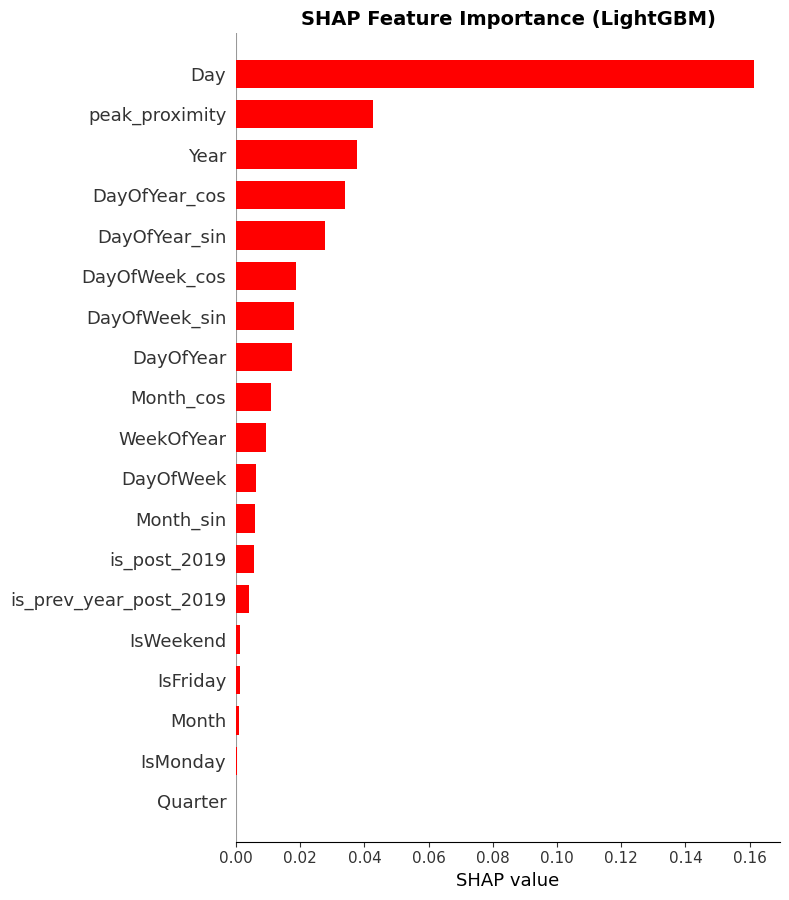

In [ ]:


print("Tính toán SHAP values cho mô hình LightGBM...")
# Dùng mô hình LightGBM đã train trên toàn bộ dữ liệu (f_rev_lgb)
explainer = shap.TreeExplainer(f_rev_lgb)

# Để tiết kiệm thời gian, ta lấy một mẫu ngẫu nhiên 5000 dòng từ tập train
X_sample = df_train_full_fe[features].sample(min(5000, len(df_train_full_fe)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Vẽ biểu đồ mức độ quan trọng của đặc trưng (Feature Importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False, color='red')
plt.title('SHAP Feature Importance (LightGBM)', fontsize=14, fontweight='bold')
plt.xlabel('SHAP value')
plt.tight_layout()
plt.show()


Tính toán SHAP values cho mô hình XGBoost...


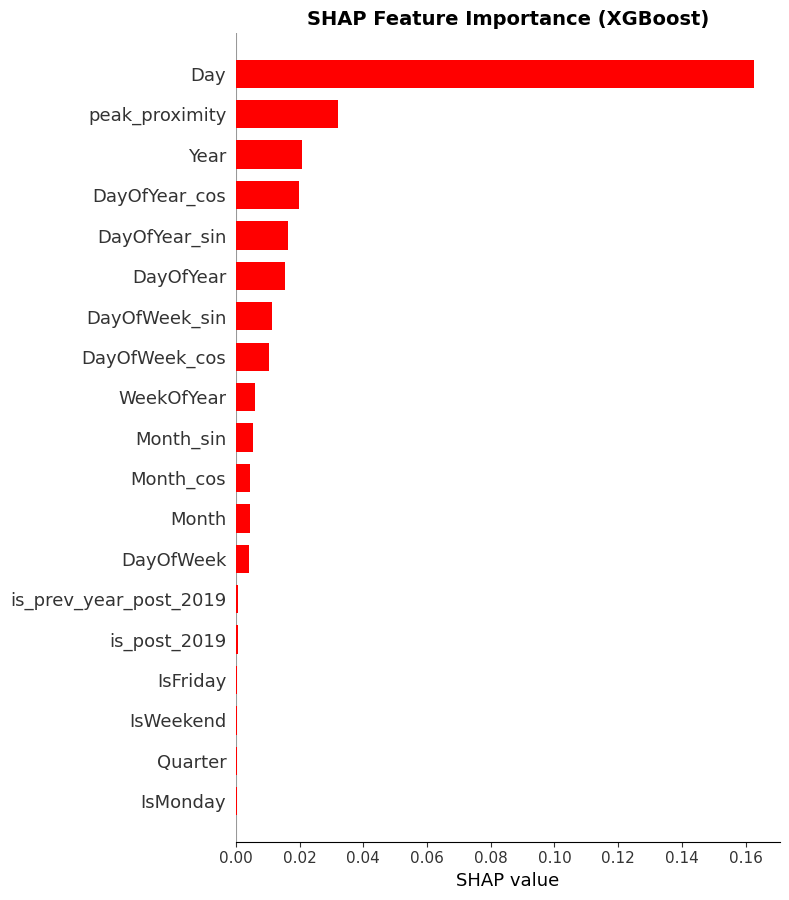

In [134]:


print("Tính toán SHAP values cho mô hình XGBoost...")
explainer = shap.TreeExplainer(f_rev_xgb)

# Để tiết kiệm thời gian, ta lấy một mẫu ngẫu nhiên 5000 dòng từ tập train
X_sample = df_train_full_fe[features].sample(min(5000, len(df_train_full_fe)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Vẽ biểu đồ mức độ quan trọng của đặc trưng (Feature Importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False, color='red')
plt.title('SHAP Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('SHAP value')
plt.tight_layout()
plt.show()

Tính toán SHAP values cho mô hình CatBoost...


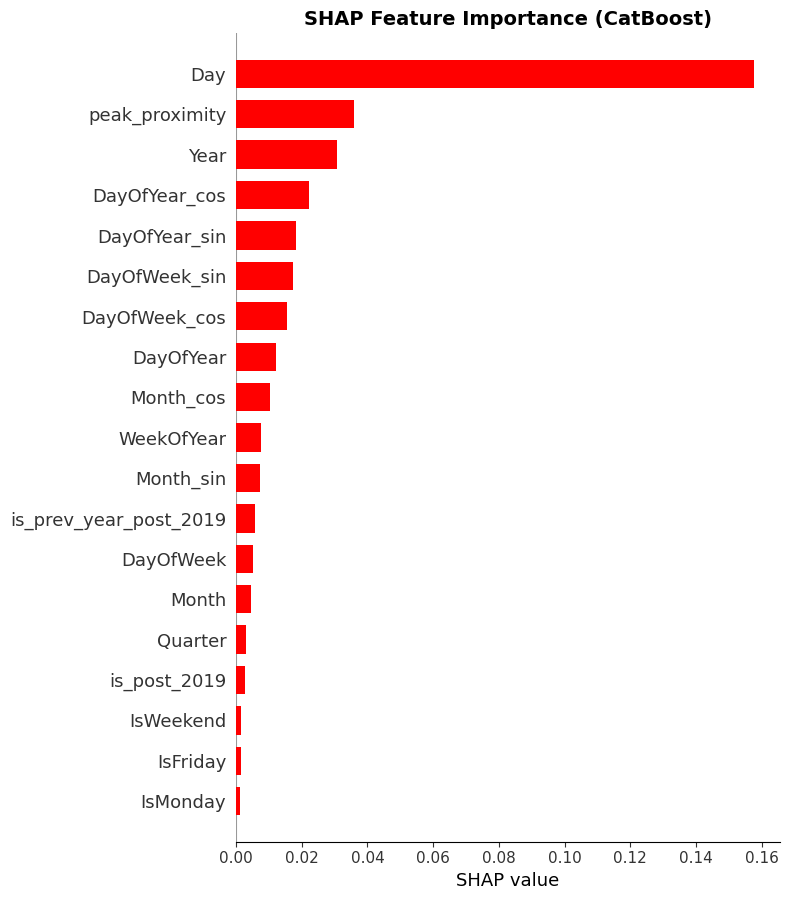

In [135]:
print("Tính toán SHAP values cho mô hình CatBoost...")
explainer = shap.TreeExplainer(f_rev_cat)

# Để tiết kiệm thời gian, ta lấy một mẫu ngẫu nhiên 5000 dòng từ tập train
X_sample = df_train_full_fe[features].sample(min(5000, len(df_train_full_fe)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Vẽ biểu đồ mức độ quan trọng của đặc trưng (Feature Importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False, color='red')
plt.title('SHAP Feature Importance (CatBoost)', fontsize=14, fontweight='bold')
plt.xlabel('SHAP value')
plt.tight_layout()
plt.show()